📍**Extração (coleta)** - Coleta de dados da fonte para a disponibilização de dados para etapas seguintes



In [ ]:
# Importa bibliotecas para análise e visualização de dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('dados_tratados.csv')
df.head(1)

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3


In [ ]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


📍 **Pré-processamento** - É a etapa de limpeza, tratamento de nulos, normatização, transformação e padronização para preparar os dados para análise eficiente e confiável.


In [ ]:
# Removendo colunas irrelevantes
df = df.drop(columns=['CustomerID'])

In [ ]:
df.head(1)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3


In [ ]:
# Agrupando No e No service
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace( 'No internet service', 'No')

In [ ]:
# Verificando novamente de valore nulos
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


📈 **EDA - Exploratory Data Analysis** - Análise Exploratória de Dados é o processo de explorar dados, visualização, detecção de outliers, ou seja entender padrões, distribuições e possíveis problemas.

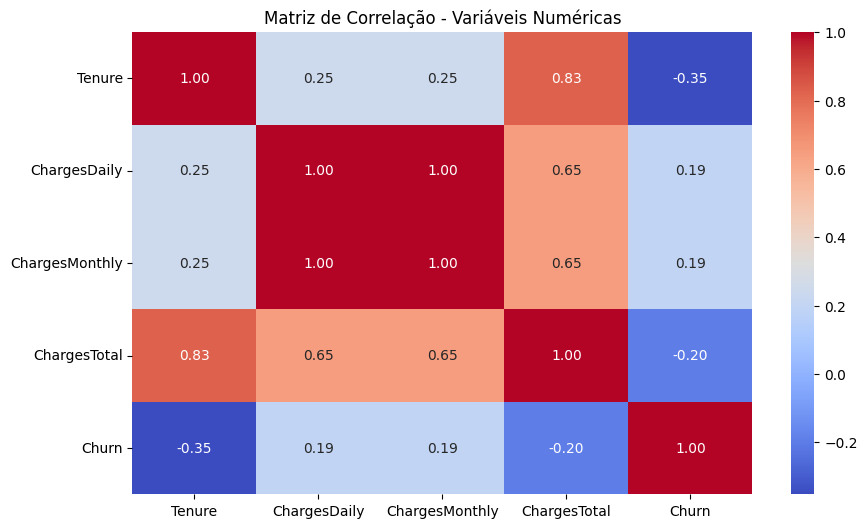

In [ ]:
#Correlação entre variaveis numericas

# Selecionar apenas variáveis numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Converter Churn para numérico
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Calcular matriz de correlação
corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()


In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

In [ ]:
# Tabela de proporção de churn por categoria

for col in categorical_cols:
    print(f"\n📌 Análise da variável: {col}")
    #Ele cria uma tabela de porcentagem de churn dentro de cada categoria de uma variável.
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Análise da variável: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Análise da variável: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Análise da variável: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Análise da variável: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Análise da variável: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


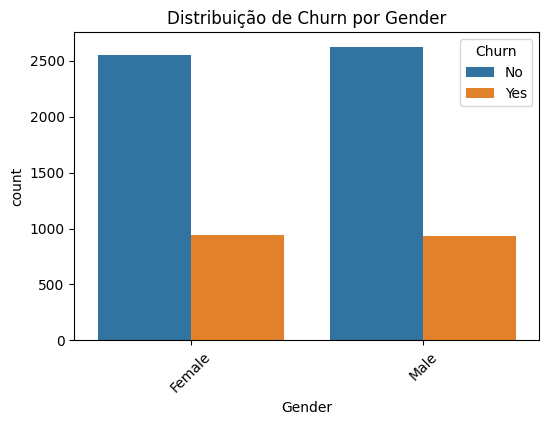

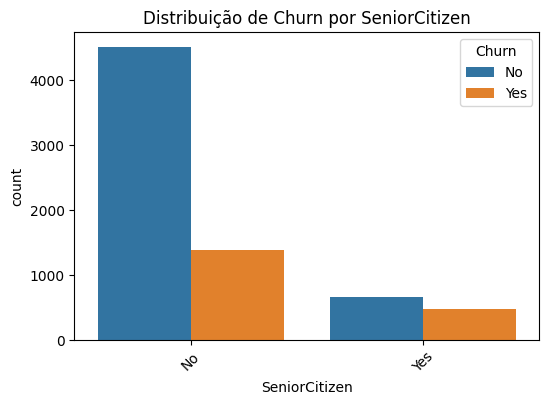

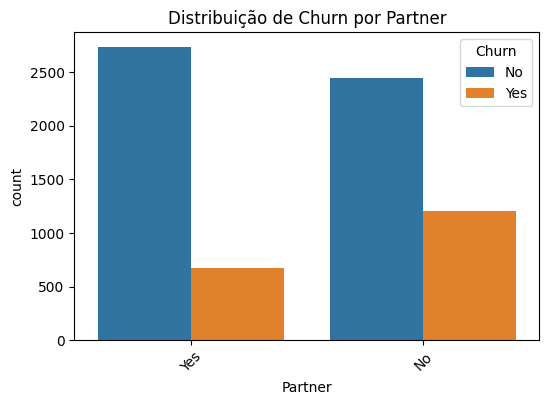

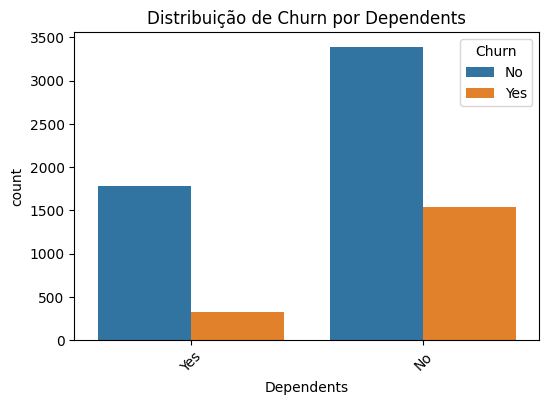

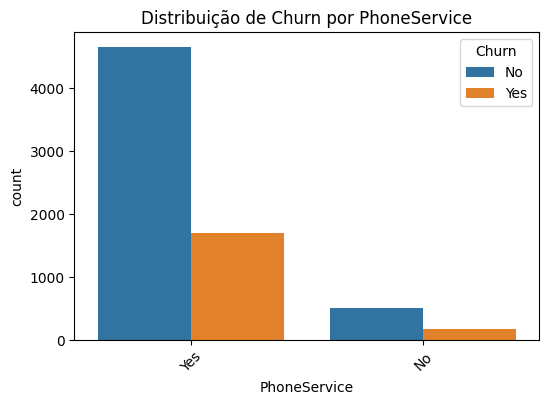

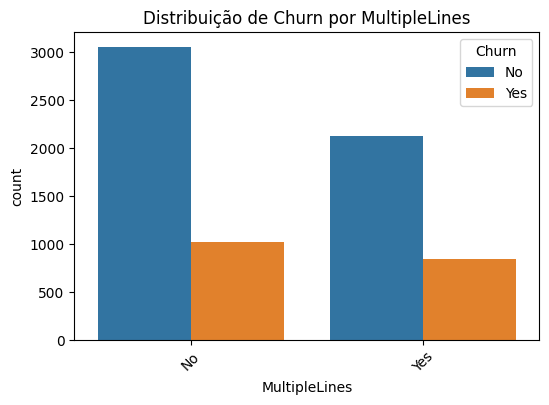

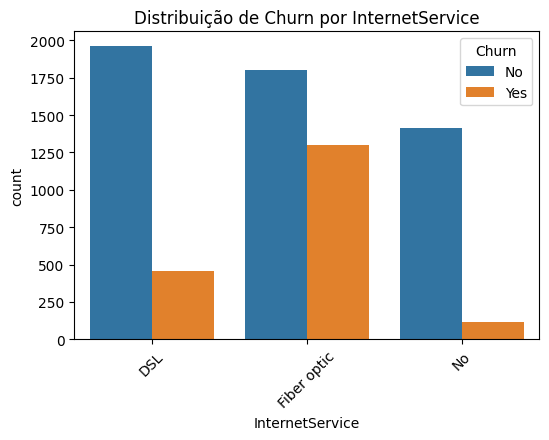

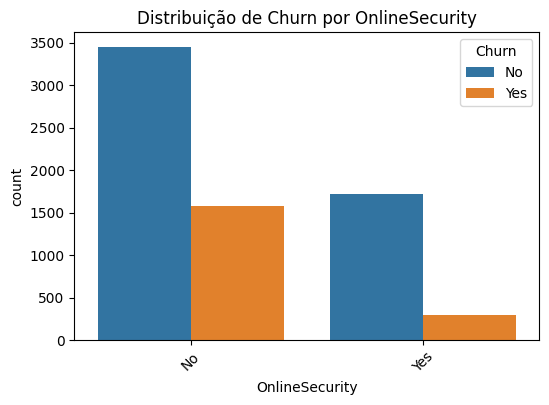

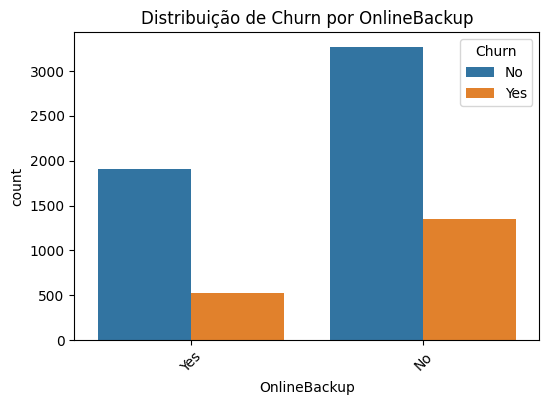

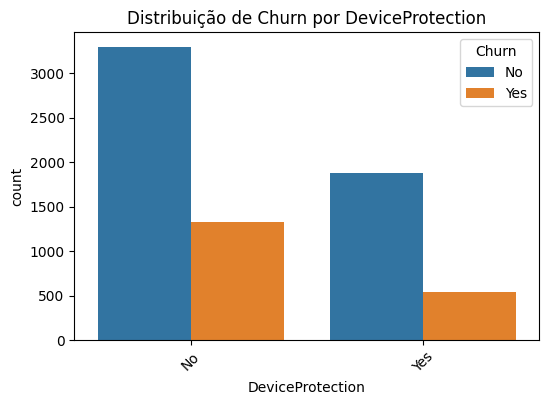

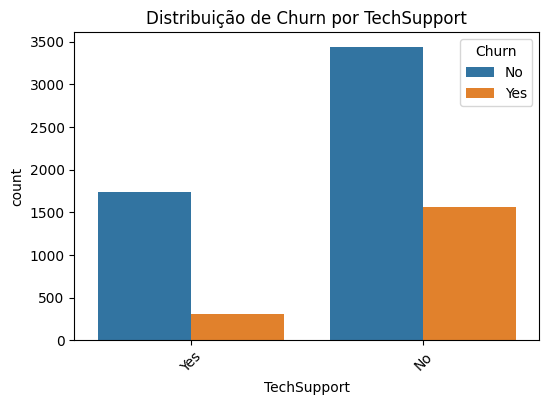

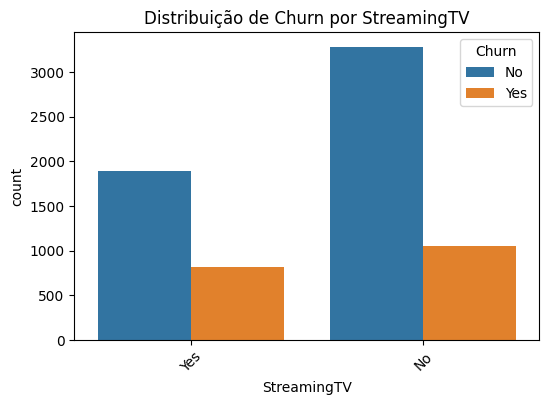

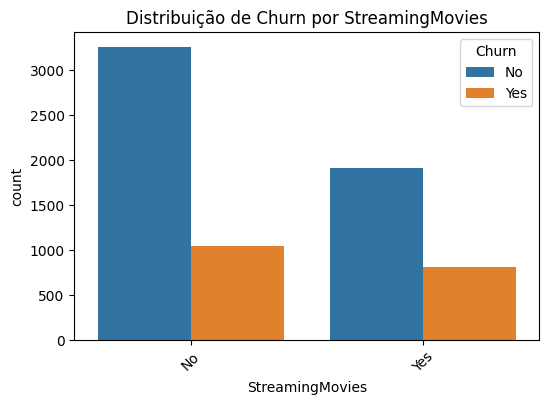

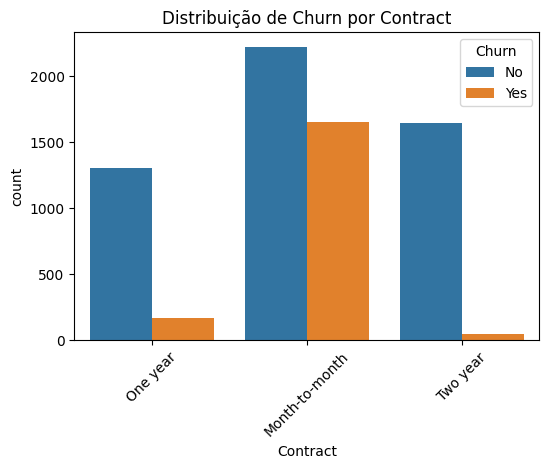

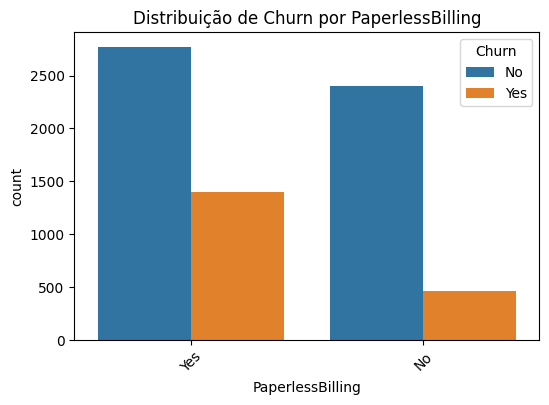

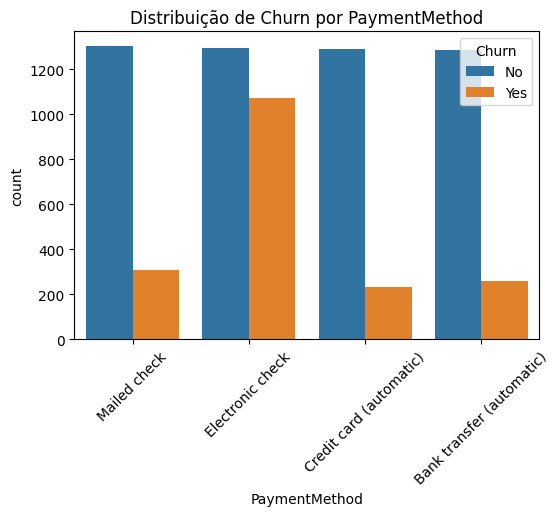

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"Distribuição de Churn por {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Importando bibliotecas de pre-processamento LabelEncoder e Chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Criar cópia
df_rank = df.copy()

# Converter Churn para binário
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variáveis categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporário (apenas para teste estatístico)
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-quadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variável": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importância
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df


,Variável,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [ ]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]
print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variável,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [ ]:
# Excluindo colunas - Gender e PhoneService
df = df.drop(columns=['Gender','PhoneService'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   object 
 15  PaymentMethod     7043 non-null   object 
 16  ChargesDaily      7043 non-null   float64


 📝 **Split** - É divisão de dados, treino e teste, validação para garantir que o modelo seja avaliado.

In [ ]:
# 1. Separação de X e Y
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
# 2. Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# 3. Conferindo o tamanho das fatias (opcional, mas recomendado)
print("Tamanho do Treino:", X_train.shape)
print("Tamanho do Teste:", X_test.shape)

Tamanho do Treino: (5634, 18)
Tamanho do Teste: (1409, 18)


In [ ]:
#4. One-Hot Encoding

# Aplicar One-Hot Encoding no treino
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar no teste
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que treino e teste tenham as mesmas colunas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
X_train.head(1)

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,3.14,94.1,5475.9,False,True,False,True,True,False,...,False,False,False,True,False,False,True,True,False,False


In [ ]:
 # 5. Verificar desbalaceamento
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.464679
Yes,26.535321


✅ **Treinamento** - É o processo de ensinar um modelo para ser capaz de generalizar e prever corretamente em novos dados.

In [ ]:
# Modelo 1 - Regressão Logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("Regressão Logística")
print(classification_report(y_test, y_pred_log_normal))

Regressão Logística
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Modelo 2 - Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.82      0.89      0.86      1035
         Yes       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
# Balanceamento - Modelo 1 - Regressão Logistica
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.91      0.72      0.80      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


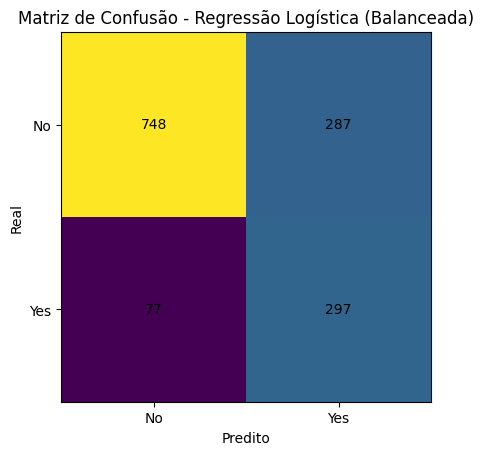

In [ ]:
# Matrix de Confusão - Regressão Logística (Balanceada)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusão - Regressão Logística (Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")

# Colocar números dentro da matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

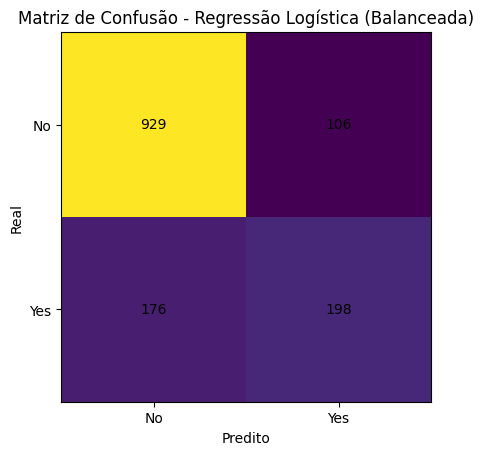

In [ ]:
# Matrix de Confusão - Regressão Logística (Balanceada) - Log normal
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusão - Regressão Logística (Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")

# Colocar números dentro da matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

# 📊 RELATÓRIO DE ANÁLISE DE EVASÃO DE CLIENTES (CHURN)

Autor: Leonardo Santos

Projeto: Desenvolvido como parte do programa Oracle Next Education (ONE) em parceria com a Alura.

---

## 1️⃣ Introdução

O objetivo deste estudo foi identificar os principais fatores que influenciam a evasão de clientes (churn) em uma empresa de telecomunicações, utilizando técnicas de análise estatística e modelos de machine learning.

A base de dados contém **7.043 clientes**, com 22 variáveis relacionadas a:

* Perfil do cliente
* Tipo de contrato
* Serviços contratados
* Forma de pagamento
* Tempo de permanência
* Valor mensal

A variável alvo analisada foi **Churn** (Yes/No).

---

## 2️⃣ Análise Exploratória dos Dados (EDA)

### Distribuição da variável alvo

* **73,46%** → Clientes que NÃO cancelaram
* **26,53%** → Clientes que cancelaram

> **📌 Observação:** Isso mostra um desbalanceamento moderado nos dados, o que justificou o uso de um modelo com `class_weight="balanced"` nas etapas posteriores.

---

## 3️⃣ Principais Fatores Identificados na Análise Exploratória

🔥 **Fatores com MAIOR impacto na evasão:**

### 1. Tipo de Contrato (Contract)

| Tipo | % Churn |
| --- | --- |
| Month-to-month | **42,7%** |
| One year | 11,2% |
| Two year | 2,8% |

> 📌 **Principal fator disparado.** Clientes com contrato mensal têm probabilidade extremamente maior de evasão.

### 2. Serviço de Internet (InternetService)

| Tipo | % Churn |
| --- | --- |
| Fiber optic | **41,9%** |
| DSL | 18,9% |
| Sem internet | 7,4% |

> 📌 **Clientes com fibra óptica evadem mais.** Possível causa: preço mais alto ou insatisfação com a qualidade.

### 3. Método de Pagamento (PaymentMethod)

| Método | % Churn |
| --- | --- |
| Electronic check | **45,2%** |
| Cartão automático | ~15% |
| Transferência automática | ~16% |

> 📌 Pagamento via **boleto eletrônico** está fortemente associado à evasão.

### 4. Serviços de Segurança e Suporte

Clientes que **não possuem** os seguintes serviços apresentam taxas altas de churn:

* **OnlineSecurity** → 31% churn
* **TechSupport** → 31% churn
* **Dependents** → 31% churn
* **Partner** → 32% churn

> 📌 Clientes com esses serviços agregados apresentam evasão significativamente menor.

---

## 4️⃣ Teste Estatístico (Chi-Quadrado)

As variáveis **mais estatisticamente significativas** foram:

* Contract (p < 0.0001)
* OnlineSecurity
* TechSupport
* SeniorCitizen
* Dependents
* PaperlessBilling
* Partner
* PaymentMethod

*Nota: `Gender` e `PhoneService` NÃO foram significativos.*

> 📌 **Conclusão estatística:** O tipo de contrato é o fator mais determinante da evasão.

---

## 5️⃣ Modelos Preditivos e Desempenho

Foram testados três modelos para a previsão de Churn. Abaixo estão os resultados para a classe "Yes" (evasão):

### 🔹 1. Regressão Logística (Normal)

* **Accuracy Geral:** 80%
* **Precision:** 0.65
* **Recall:** 0.52
* **F1-score:** 0.58

> 📌 **Problema:** O modelo não identifica bem os clientes que realmente evadem (recall baixo).

### 🔹 2. Random Forest

* **Accuracy Geral:** 78%
* **Precision:** 0.62
* **Recall:** 0.48
* **F1-score:** 0.54

> 📌 **Problema:** Desempenho inferior à Regressão Logística.

### 🔹 3. Regressão Logística Balanceada (MELHOR MODELO)

* **Accuracy Geral:** 74%
* **Precision:** 0.51
* **Recall:** 0.79
* **F1-score:** 0.62

> 📌 **Esse é o modelo mais adequado para churn.** Apesar da menor *accuracy* geral, ele identifica **79% dos clientes que realmente vão cancelar**. Em problemas de churn, o *Recall* é a métrica mais importante.

---

## 6️⃣ Principais Fatores que Afetam a Evasão (Conclusão Integrada)

Combinando a Análise Exploratória, o Teste Estatístico e os Resultados dos Modelos, os principais fatores de risco são:

* 🥇 **1. Contrato mensal (Month-to-month):** Maior fator de risco.
* 🥈 **2. Pagamento via Electronic Check:** Clientes menos comprometidos e mais propensos a cancelar.
* 🥉 **3. Ausência de serviços de suporte/segurança:** Clientes sem *TechSupport*, *OnlineSecurity* e *DeviceProtection* evadem mais.
* 🔹 **4. Clientes SeniorCitizen:** Apresentam maior taxa de evasão.
* 🔹 **5. Clientes sem dependentes ou parceiro:** Menor vínculo familiar gera maior risco de saída.

---

## 7️⃣ Estratégias de Retenção Propostas

Com base nos resultados, sugerimos as seguintes ações táticas:

* 🎯 **1. Estratégia para Contrato Mensal:** * Oferecer desconto para migração para plano anual.
* Oferecer benefícios exclusivos para contratos de longo prazo (Programa de fidelidade).


* 💳 **2. Estratégia para Electronic Check:** * Incentivo financeiro para migração para débito automático.
* Oferecer cashback ou desconto na primeira fatura após a troca.


* 🛡 **3. Upsell de Serviços de Segurança:** * Clientes sem *OnlineSecurity* e *TechSupport* devem receber uma oferta personalizada (ex: pacote promocional de proteção).
* 👴 **4. Programa para SeniorCitizen:** * Atendimento especializado com suporte simplificado e canal dedicado.
* 📅 **5. Estratégia para Clientes Novos (baixo Tenure):** * Criar programa de *onboarding* nos primeiros 90 dias com contato proativo de acompanhamento.

---

## 8️⃣ Conclusão Final

O estudo demonstrou que a evasão é fortemente influenciada por quatro pilares:

1. **Tipo de contrato**
2. **Método de pagamento**
3. **Serviços agregados**
4. **Perfil do cliente**

O modelo mais adequado para prever o churn de forma proativa foi a **Regressão Logística com balanceamento de classes**, apresentando um excelente **Recall de 79%** para clientes evasores.

---
